## Gamma Ray Bursts.
Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 




In [2]:
import requests 
import numpy as np
import pylab as plt

from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix


# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\Martina\AppData\Local\Temp\ipykernel_7312\3054945284.py:17: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [3]:
print(names)
print(data.shape)
#Alcune variabili che mi sembrano interessanti potrebbero essere
#T90 =          Duration of the time interval during which 90% of the GRB photon counts are observed
#T90_error =    Estimated 1σ error on the duration of the T90 interval.
#redshift =  	Distance to the GRB 
#fluence =      The time integrated total energy per unit surface

['GRB_name' 'GRB_name_Fermi' 'T0' 'ra' 'decl' 'pos_error' 'T90'
 'T90_error' 'T90_start' 'fluence' 'fluence_error' 'redshift' "'T100'"
 'GBM_located' 'mjd_(T0)']
(15, 9170)


da https://doi.org/10.1016/j.asr.2010.08.009 "Gamma ray bursts: Short vs. long", alcune osservazioni:

~Short and long GRBs are thought to be two distinct classes based on their different duration  \
~The spectral analysis of two similarly selected samples of BATSE short and long GRBs, we show that short GRBs are harder than long events, this spectral diversity seems to be due to a harder low energy spectral component of short GRBs ( hardness ratio HR – defined as the ratio of the counts in two contiguous energy ranges) \
~SHORT: merge of two compact objects vs LONG: core collapse of a massive star

Analizziamo la durata T90, ci aspettiamo una bimodale con una divisione a ~2sec 

In [4]:
t90_data = np.array(data[6,:], dtype = 'float')
t90_error = np.array(data[7,:], dtype = 'float')
redshift_data = np.array(data[11,:], dtype = 'float')
fluence_data = np.array(data[9,:], dtype = 'float')
fluence_error = np.array(data[10,:], dtype = 'float')

C:\Users\Martina\AppData\Local\Temp\ipykernel_7312\3040126148.py:2: RuntimeWarning: invalid value encountered in log10
  logt90_data = np.log10(t90_data)


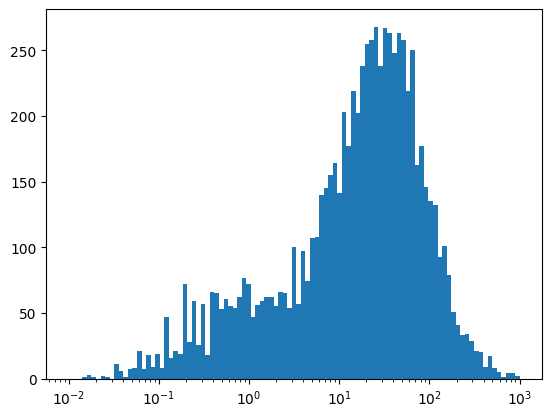

In [5]:
#vediamo un istogramma dei t90, la durata del burst; usiamo dei bin logaritmici per osservare bene la scala dei tempi reali
logt90_data = np.log10(t90_data)
plt.hist(t90_data, bins = np.logspace(-2,3,100)); 
plt.semilogx();
plt.show() #Emerge la divisione tra 1 e 10 secondi

In [6]:
#Usiamo una KDE per un fit con sklearn, dunque formattiamo con un nuovo asse
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV #usiamo gridsearchCV per trovare la miglior bw

def kde_sklearn(data, bandwidth, xgrid):
    kde_skl = KernelDensity(bandwidth = bandwidth)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

logt90_data = logt90_data[~np.isnan(logt90_data)]

In [7]:
#bwrange = np.linspace(0.01,1.0, 40)
#K = 5 #5- fold cross validation
#grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K)

#grid.fit(logt90_data[:, None]) 

#h_opt = grid.best_params_['bandwidth']
#print(h_opt)

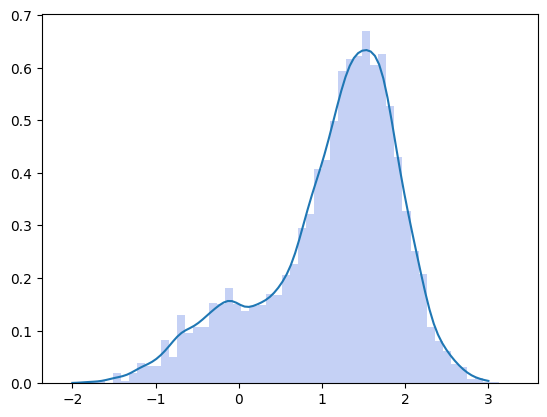

In [8]:
h_opt = 0.11153846153846153
x = np.linspace(-2,3,100)
logt90_pdf = kde_sklearn(logt90_data, bandwidth = h_opt, xgrid = x)
plt.plot(x, logt90_pdf)
plt.hist(logt90_data, bins = 'auto', density=True, alpha = 0.3, color = 'royalblue'); 
plt.show() #Emerge la divisione tra 1 e 10 secondi


In [9]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(logt90_data[:,np.newaxis])

,"n_components n_components: int, default=1The number of mixture components.",2
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [10]:
means = gmm.means_.flatten() # The mean of each mixture component.

prob_separation_axis = np.linspace(logt90_data.min(), logt90_data.max(), 10000)
prob_separation_axis = prob_separation_axis[:,np.newaxis]
prob_separation = gmm.predict_proba(prob_separation_axis)
mask_separation = prob_separation[:, 0] >= 0.5
idx_separation = np.where(mask_separation)[0][0]

print(f"Le medie dei due modi sono: {10**means} con una separazione stimata attorno a {10**prob_separation_axis[idx_separation]}") 

# I GRB Long hanno una media di 30 secondi, quelli short si attestano sugli 0.9 secondi

Le medie dei due modi sono: [30.46133333  0.96218299] con una separazione stimata attorno a [3.82928272]


In [11]:
#Abbiamo usato la cross-validation per la gridsearch della bandwidth ottimale. Adesso passiamo agli algoritmi unsupervised per cercare
#i due cluster. Partiamo dal KMeans

from sklearn.cluster import KMeans
from sklearn import preprocessing
kmeans = KMeans(n_clusters = 2, n_init = 'auto')
kmeans.fit(logt90_data[:,np.newaxis])


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [12]:
#Possiamo vedere un po' di cose, ad esempio se i centroid sono compatibili con le medie della gaussian mixture 
centroids = kmeans.cluster_centers_
centroids_sec = 10**np.squeeze(centroids)
print(centroids_sec)
#Più o meno ci siamo! Salviamoci anche i labels per ogni punto. Ricordiamoci che 0 = LONG, 1 = Short
labels = kmeans.predict(logt90_data[:,np.newaxis])
print(labels)

#Per trovare la separazione adesso vediamo quando finiscono gli 0 e iniziano gli 1,ovviamente ordinando l'array
if centroids[0]>centroids[1]:
    centroids=centroids[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1

centroids_sec = 10**np.squeeze(centroids)
print(centroids_sec)
print(labels)

separation_Kmeans = 10**( np.mean( [max(logt90_data[labels==0]), min(logt90_data[labels==1]) ]))
print(separation_Kmeans)

[32.53648543  0.8762678 ]
[1 0 0 ... 1 0 1]
[ 0.8762678  32.53648543]
[0 1 1 ... 0 1 0]
5.330966141329357


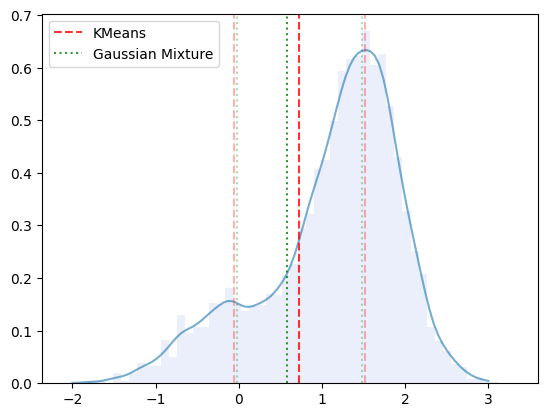

In [13]:
plt.plot(x, logt90_pdf, alpha = 0.6)
plt.hist(logt90_data, bins = 'auto', density=True, alpha = 0.1, color = 'royalblue'); 

plt.axvline(np.log10(separation_Kmeans), c = 'red', label = 'KMeans', ls = '--', alpha = 0.8)
plt.axvline(centroids[0], c = 'red', ls = '--', alpha = 0.3)
plt.axvline(centroids[1], c = 'red', ls = '--', alpha = 0.3)

plt.axvline(prob_separation_axis[idx_separation], c = 'green', label = 'Gaussian Mixture', ls = 'dotted', alpha = 0.8)
plt.axvline(means[0], c = 'green', ls = 'dotted', alpha = 0.3)
plt.axvline(means[1], c = 'green', ls = 'dotted', alpha = 0.3)

plt.legend()
plt.show() #Emerge la divisione tra 1 e 10 secondi


In [14]:
#Proviamo anche con il Mean Shift
from sklearn.cluster import MeanShift

#scaler = preprocessing.StandardScaler()

ms = MeanShift(bandwidth = h_opt, bin_seeding = True, cluster_all = False)
ms.fit(logt90_data[:, np.newaxis])

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",0.11153846153846153
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


In [15]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
#print(bandwidth)
print("number of estimated clusters :", n_clusters)

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
number of estimated clusters : 17


La bandwidth calcolata dal KDE è troppo stretta per il Mean Shift, sta calcolando troppi clusters. Proviamo ad usare estimate_bandwidth di Sklearn MeanShift

In [16]:
from sklearn.cluster import estimate_bandwidth
scaler = preprocessing.StandardScaler()
bandwidth = estimate_bandwidth(logt90_data[:, np.newaxis])
ms = MeanShift(bandwidth = bandwidth, bin_seeding = True, cluster_all = False) #cluster_all rende meno pesanti gli outliers che verrebbero aggregati al centroide più vicino anche se estremamente lontani e poco popolati
ms.fit(scaler.fit_transform(logt90_data[:, np.newaxis]))

,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(0.5170688605505034)
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


In [17]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth) #La bandwidth stimata è 0.5
print("number of estimated clusters :", n_clusters)

[-1  0  1]
0.5170688605505034
number of estimated clusters : 2


0.3174901573277509
[[-0.07707629]
 [ 1.49316959]]


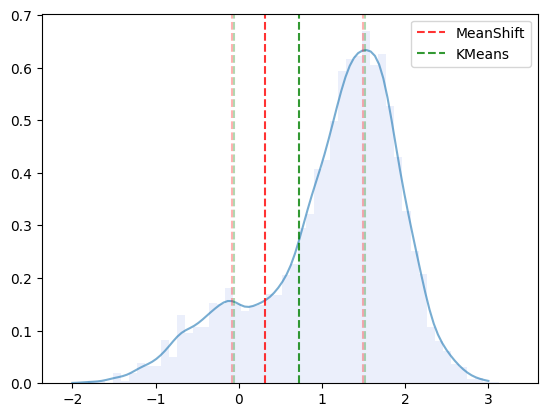

In [18]:
plt.plot(x, logt90_pdf, alpha = 0.6)
plt.hist(logt90_data, bins = 'auto', density=True, alpha = 0.1, color = 'royalblue'); 

labels = ms.predict(logt90_data[:,np.newaxis])
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
if cluster_centers[0,0]>cluster_centers[1,0]:
    cluster_centers=cluster_centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1



edge = 10**( np.mean( [max(logt90_data[labels==0]), min(logt90_data[labels==1]) ]))

print(edge)


print(cluster_centers)
plt.axvline(edge, c = 'red', label = 'MeanShift', ls = '--', alpha = 0.8)
plt.axvline(cluster_centers[0,0], c = 'red', ls = '--', alpha = 0.3)
plt.axvline(cluster_centers[1,0], c = 'red', ls = '--', alpha = 0.3)

plt.axvline(np.log10(separation_Kmeans), c = 'green', label = 'KMeans', ls = '--', alpha = 0.8)
plt.axvline(centroids[0], c = 'green', ls = '--', alpha = 0.3)
plt.axvline(centroids[1], c = 'green', ls = '--', alpha = 0.3)

plt.legend()

La T90 non è l'unica variabile, possiamo ad esempio considerare anche la fluence, ovvero l'energia per unità di surface mediata nel tempo

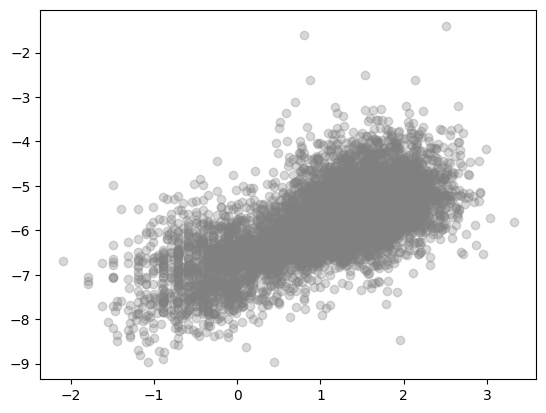

In [19]:
t90_data = t90_data.squeeze()
fluence_data = fluence_data.squeeze()
mask = (t90_data > 0) & (fluence_data > 0) #togliere i -inf e i nan per il log
t90_data = t90_data[mask]
fluence_data = fluence_data[mask]

logt90_data = np.log10(t90_data) #per avere la stessa lunghezza di fluence
logfluence_data = np.log10(fluence_data)

plt.scatter(logt90_data, logfluence_data, alpha = 0.3, c = 'grey')
plt.show()

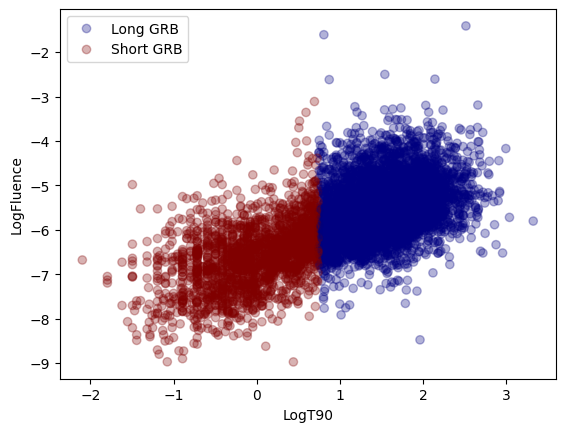

In [20]:
#Possiamo checkare i colori dei label assegnati dal Kmeans

kmeans = KMeans(n_clusters = 2, n_init = 'auto')
kmeans.fit(logt90_data[:,np.newaxis])
labels = kmeans.predict(logt90_data[:,np.newaxis])


scatter = plt.scatter(logt90_data, logfluence_data, alpha = 0.3, c = labels,cmap='jet')

handles, _ = scatter.legend_elements()
plt.xlabel('LogT90')
plt.ylabel('LogFluence')
plt.legend(handles, ["Long GRB", "Short GRB"])
plt.show()

Emerge che i Long GRB hanno un'energia media nel tempo per unità di superficie più alta degli Short, nonostante per l'appunto la durata. Ipotizzo che sia legato al fenomeno di generazione dei due cluster di GRB.

Un'altra variabile interessante è il redshift, vediamo se riusciamo ad identificare una diversità nelle due classi

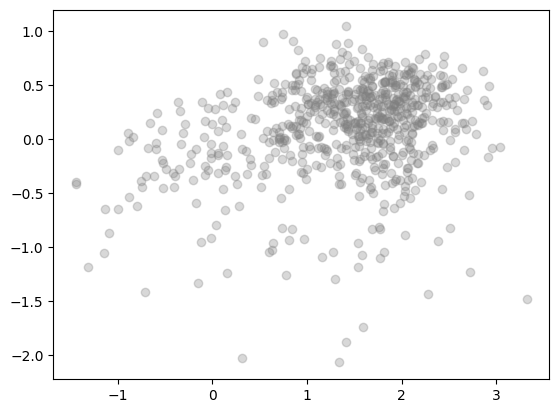

In [21]:
t90_data = np.array(data[6,:], dtype = 'float').squeeze()
redshift_data = np.array(data[11,:], dtype = 'float').squeeze()
fluence_data = np.array(data[9,:], dtype = 'float').squeeze()
mask = (t90_data > 0) & (redshift_data > 0) & (fluence_data > 0) #togliere i -inf e i nan per il log
t90_data = t90_data[mask]
redshift_data = redshift_data[mask]
fluence_data = fluence_data[mask]

logt90_data = np.log10(t90_data) #per avere la stessa lunghezza di fluence
logredshift_data = np.log10(redshift_data)
logfluence_data = np.log10(fluence_data)
plt.scatter(logt90_data, logredshift_data, alpha = 0.3, c = 'grey')
plt.show()

[0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0
 1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 1 1 0 1
 1 1 0 0 0 1 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 1 1
 1 1 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 0 1 1 1 0 0 0 1 1 0 1 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 1 1 1 0 1 1 0 0
 0 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 0
 1 0 0 0 1 1 0 0 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 1 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1
 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1
 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 0 1 0 0 0 0 0 1 0
 0 0 0 1 0 0 0 0 0 0 0 0 

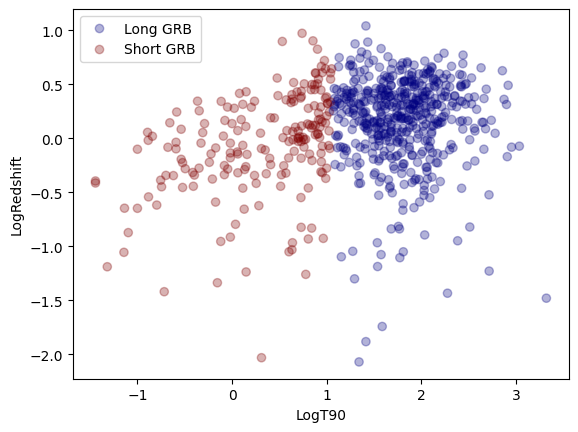

In [25]:
#Possiamo checkare i colori dei label assegnati dal Kmeans

kmeans = KMeans(n_clusters = 2, n_init = 'auto')
kmeans.fit(logt90_data[:,np.newaxis])
labels = kmeans.predict(logt90_data[:,np.newaxis])

print(labels)
means = gmm.means_.flatten()
print(10**means)


idx_short = np.argmin(means)  
idx_long = np.argmax(means)  

nomi_legenda = [""] * 2
nomi_legenda[idx_short] = "Short GRB"
nomi_legenda[idx_long] = "Long GRB"

scatter = plt.scatter(logt90_data, logredshift_data, alpha = 0.3, c = labels,cmap='jet')

handles, _ = scatter.legend_elements()
plt.xlabel('LogT90')
plt.ylabel('LogRedshift')
plt.legend(handles, ["Long GRB", "Short GRB"])
plt.show()

Anche in questo caso emerge una distinzione notevole tra i due cluster, gli short GRB sono causati da meccanismi di merge tra stelle, un fenomeno che richiede maggiore tempo e dunque quando avviene l'evento siamo in un'età più giovane. Sono eventi con una durata minore e una fluence minore, tuttavia dal paper in questione se non sbaglio comunque osserveremmo un picco più alto. Allo stesso tempo, i Long GRB hanno un'energia per unita di superficie più grande e provengono da fenomeni più vecchi, come il collasso di stelle massicce.

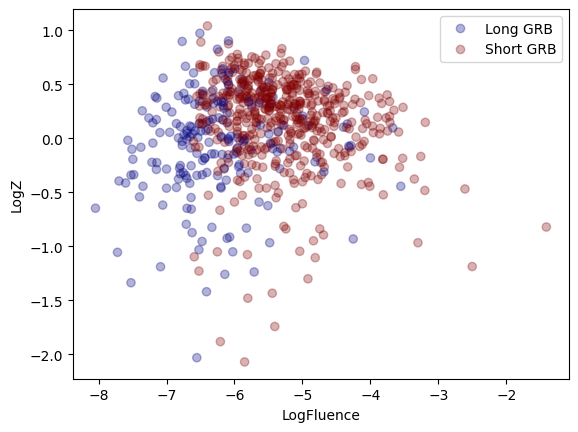

In [23]:
#FAI FLUENCE VS REDSHIFT
#Possiamo checkare i colori dei label assegnati dal Kmeans

scatter = plt.scatter(logfluence_data, logredshift_data, alpha = 0.3, c = labels,cmap='jet')

handles, _ = scatter.legend_elements()

plt.legend(handles, ["Long GRB", "Short GRB"])
plt.xlabel('LogFluence')
plt.ylabel('LogZ')
plt.show()
#USA RA E DECL 

logT90, logRedShift, logFluence
[[ 0.69895022  0.3355893   0.63154447]
 [-0.03392319  0.89763184 -0.43943861]]


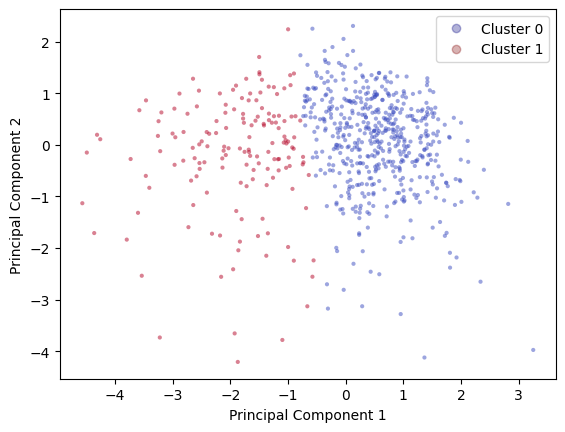

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
pca = PCA(n_components=2)
X = np.vstack([[logt90_data], [logredshift_data], [logfluence_data], ]).T
scaler = StandardScaler()
X = scaler.fit_transform(X)

pca.fit(X) # Do the fitting
X_PCA = pca.fit_transform(X)
#print(X_PCA)

kmeans = KMeans(n_clusters = 2, n_init = 'auto')
kmeans.fit(X_PCA)
labels = kmeans.predict(X_PCA)

plt.scatter(X_PCA[:,0], X_PCA[:,1], 
            marker=".", c=labels, cmap ='coolwarm', 
            alpha=0.5, edgecolors='None')

handles, _ = scatter.legend_elements()
plt.legend(handles, ["Cluster 0", "Cluster 1"])

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

print("logT90, logRedShift, logFluence")
pesi = pca.components_
print(pesi)